## **Task 1: Data Loading & Exploratory Data Analysis (EDA)**

#### Load the dataset 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('dataset/Mall_Customers.csv')

#### Rename and drop columns 

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.drop(columns=['CustomerID'],inplace=True)

In [5]:
df.rename(columns={'Annual Income (k$)':'Annual_Income','Spending Score (1-100)':'Spending_Score'},inplace=True)

In [6]:
df.describe()

,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


---

Numerical Data doesn't Contain Outliers by looking at Statstic of Data. 

---

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Gender          200 non-null    object
 1   Age             200 non-null    int64 
 2   Annual_Income   200 non-null    int64 
 3   Spending_Score  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


---

DataSet Contains **3** Numerical columns and **1** Categorical Column so We will Apply Label Encoding in Categorical Column and Feature Scaling in Numerical Columns.

---

#### Encode Gender 

In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
le = LabelEncoder()

In [10]:
df['Gender'] = le.fit_transform(df['Gender'])

---

By Default 0 was Assigned to Female and 1 was Assigned to Male because of Alphabetical Order.

---

#### Univariate distributions 

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

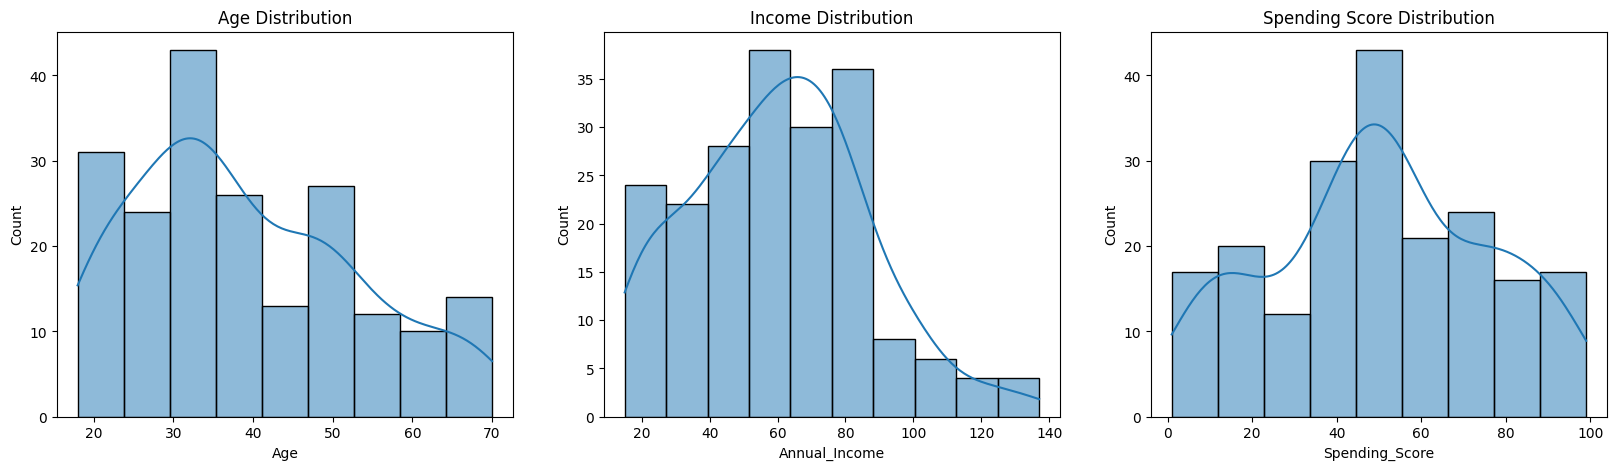

In [12]:
_,ax = plt.subplots(1,3,figsize=(20,5))

sns.histplot(data=df,x='Age',ax=ax[0],kde=True)
ax[0].set_title('Age Distribution')

sns.histplot(data=df,x='Annual_Income',ax=ax[1],kde=True)
ax[1].set_title('Income Distribution')

sns.histplot(data=df,x='Spending_Score',ax=ax[2],kde=True)
ax[2].set_title('Spending Score Distribution')

plt.savefig('figure/Data_Distribution.png',dpi=300)
plt.show()

---

**Key Takeaways from the Plots:**

* **Age**: The customer base peaks around the 30–35 age range. It's a bit right-skewed, trailing off as age increases up to 70, with a decent spike in younger customers (around 18–20).

* **Annual Income**: This follows a fairly normal distribution but is slightly right-skewed. The bulk of your customers earn between 40k and 80k, with a few high earners stretching out past 100k up to nearly 140k.

* **Spending Score**: This shows a clear, massive peak right in the middle around 40–50. The rest of the distribution is relatively uniform across the lower and higher scores.

---

#### Pairplot & correlation heatmap

---

Creating Pair plot to see all the possible Combination Between Data

---

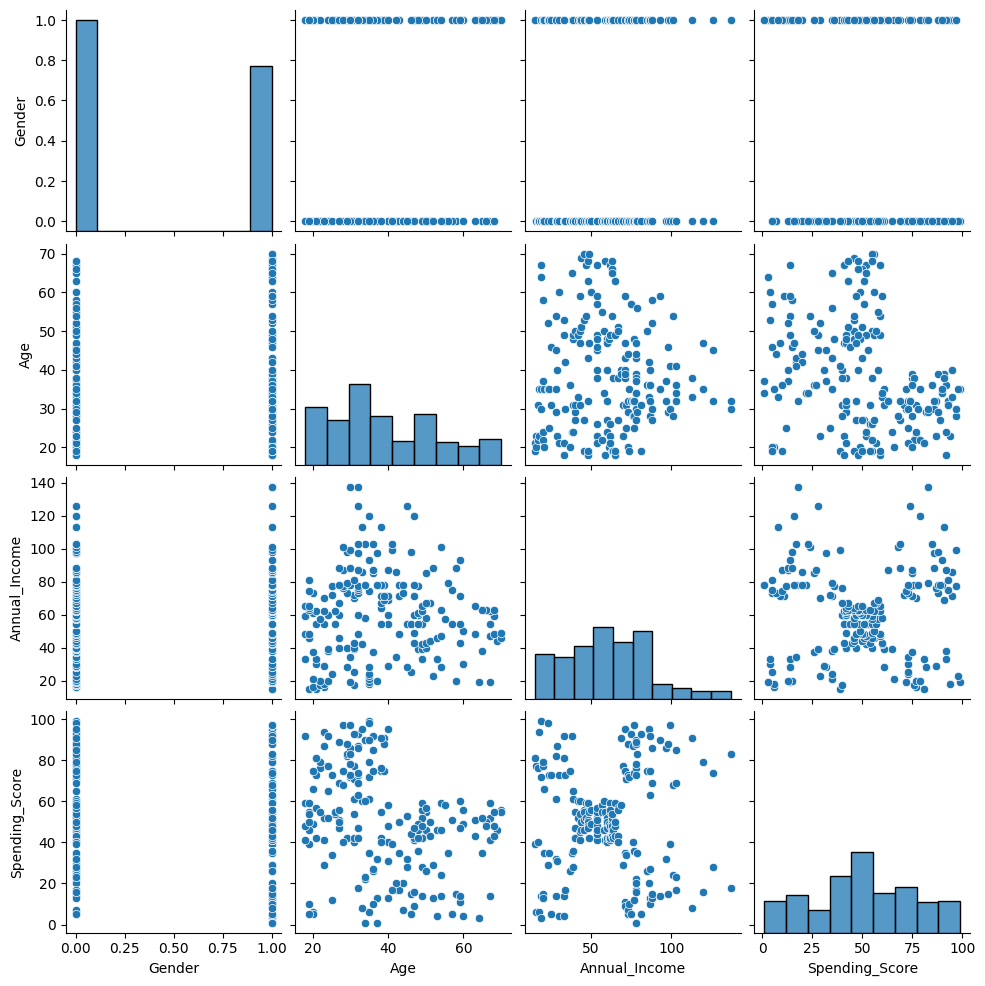

In [13]:
sns.pairplot(df,hue=None)
plt.show()

---

**The key observations from the pairplot:**

* **Clear Geometric Groupings in Annual_Income vs Spending_Score**:

  The scatter plot for this pair (visible in the third row, fourth column, and vice versa) shows a highly distinct, symmetrical 5-cluster pattern. There is a tightly packed central cluster surrounded by four well-separated corner clusters (high/low combinations of income and spending), making this the absolute best combination for visual segmentation.

* **The Upper Bound in Age vs Spending_Score**:

  The plot comparing Age and Spending_Score reveals a distinct upper boundary where customers over the age of 40 rarely cross a spending score of 60. This creates a natural, visible split between a high-spending younger cohort and a more moderate-to-low-spending older cohort.

* **Lack of Strong Linear Correlations**:

  Across almost all scatter plots, the data points show wide dispersion rather than forming tight diagonal lines. This visualizes what we saw in the correlation matrix—very weak linear relationships, which means the features provide independent dimensions of information for clustering.

* **Categorical Isolation of Gender**:

  Because Gender is encoded as a binary value (0.0 and 1.0), its scatter plots simply form vertical or horizontal parallel lines. It does not create spatial clusters on its own, confirming that it won't help separate customers into natural geometric groups compared to the continuous features.

---

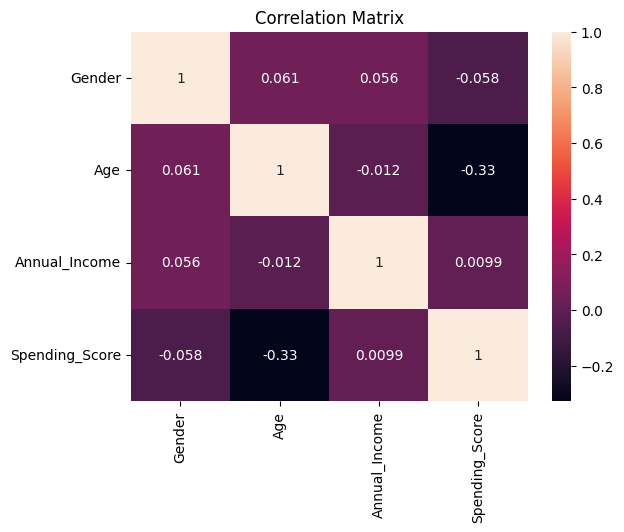

In [14]:
sns.heatmap(df.corr(),annot=True)
plt.title('Correlation Matrix')
plt.savefig('figure/Corr.png',dpi=300)
plt.show()

---

**The key points for the Correlation Matrix plot:**

* **Weak Linear Correlations Overall**: Most feature pairs show near-zero correlation, which is actually ideal for clustering because it means the variables provide independent, non-redundant pieces of information.
  
* **Strongest Relationship (Age vs. Spending_Score)**: This pair has the strongest correlation in the dataset at $-0.33$. The negative value indicates that as a customer's age increases, their spending score tends to decrease, hinting at a natural split between younger, higher-spending customers and older, more conservative spenders.

* **The Prime Clustering Candidate (Annual_Income vs. Spending_Score)**: These two variables have virtually zero linear correlation ($0.0099$). Because they don't share a linear relationship, they are free to form distinct, non-linear geometric clusters (blobs) when plotted together on a scatter plot.

* **Negligible Gender Impact**: Gender shows incredibly weak correlation values with all other features (ranging from $-0.058$ to $0.061$). This indicates that gender alone does not linearly drive income, age, or spending habits in this dataset.

---

## **Task 2: Feature Scaling & Feature Selection**

#### Scale features 

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
ss = StandardScaler()

In [76]:
# Extracting feature names for scaling

features = df.drop(columns='Gender').columns
features

Index(['Age', 'Annual_Income', 'Spending_Score', 'KMeans_Cluster'], dtype='object')

In [23]:
# Scaling values into new df 

df_scaled = pd.DataFrame(ss.fit_transform(df[features]),columns=features)

#### Select 2-feature subset

In [26]:
# Excluding age column
df_2f = df_scaled.drop(columns='Age')

We can use all 4 features but  the primary tasks use df_2f for visual clarity.

##### Why Feature Scaling (StandardScaler) is Required

Distance-based clustering algorithms (like **K-Means** and **DBSCAN**) rely on Euclidean distance to determine cluster assignments:

$$d = \sqrt{(\Delta \text{Annual\_Income})^2 + (\Delta \text{Spending\_Score})^2}$$

* **The Problem:** Without scaling, features with larger raw magnitudes and variances dominate the distance formula. Here, `Annual_Income` (range ~15–137) naturally overpowers `Spending_Score` (range 1–100). The algorithm treats a small shift in income as far more significant than a massive shift in spending behavior, effectively blinding the model to the spending patterns.
* **The Solution:** Applying `StandardScaler` standardizes both features to a mean of 0 and a standard deviation of 1. This ensures that every feature contributes equally to the distance calculations, allowing the model to uncover true, balanced multi-dimensional clusters.

## **Task 3: K-Means Clustering**

#### Elbow Method 

In [27]:
from sklearn.cluster import KMeans

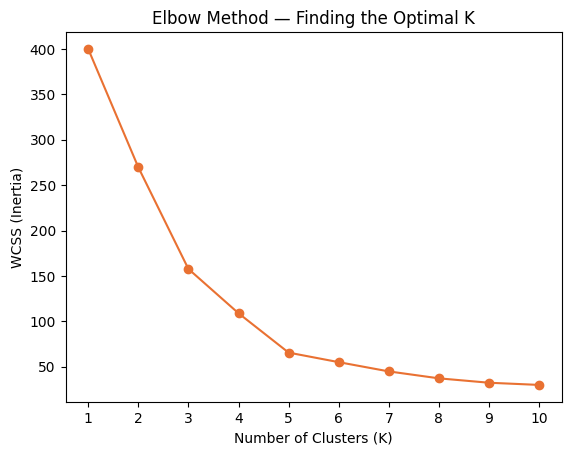

K = 1  ->  WCSS = 400.0
K = 2  ->  WCSS = 269.7
K = 3  ->  WCSS = 157.7
K = 4  ->  WCSS = 108.9
K = 5  ->  WCSS = 65.6
K = 6  ->  WCSS = 55.1
K = 7  ->  WCSS = 44.9
K = 8  ->  WCSS = 37.2
K = 9  ->  WCSS = 32.4
K = 10  ->  WCSS = 30.0


In [42]:
wcss = []
k_ranges = range(1, 11)

for k in k_ranges:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(df_2f)
    wcss.append(km.inertia_)

plt.plot(list(k_ranges), wcss, marker="o", color="#E97132")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method \u2014 Finding the Optimal K")
plt.xticks(list(k_ranges))
plt.show()

for k, w in zip(k_range, wcss):
    print(f"K = {k}  ->  WCSS = {w:,.1f}")

**5** is best K Value using Elbow Method because after K=5, Other values are close to one another which doesn't make big difference.

---

##### **what inertia measures and why the elbow indicates a good k.?**
* **Inertia (WCSS):** Measures cluster tightness by calculating the total sum of squared distances between each data point and its assigned cluster center (lower means denser clusters).
* **The Elbow:** Indicates the optimal $K$ because it represents the point of diminishing returns, where adding more clusters no longer yields a significant drop in inertia, balancing model simplicity with performance.

---

#### Silhouette Score

In [30]:
from sklearn.metrics import silhouette_score

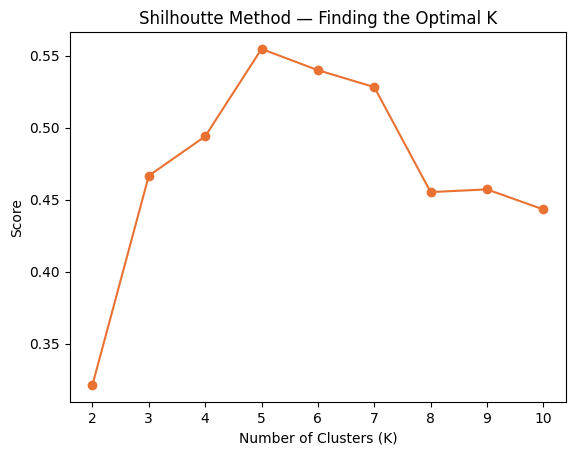

K = 2  ->  WCSS = 0.32
K = 3  ->  WCSS = 0.47
K = 4  ->  WCSS = 0.49
K = 5  ->  WCSS = 0.55
K = 6  ->  WCSS = 0.54
K = 7  ->  WCSS = 0.53
K = 8  ->  WCSS = 0.46
K = 9  ->  WCSS = 0.46
K = 10  ->  WCSS = 0.44


In [52]:
sils = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    sils.append(silhouette_score(df_2f, km.fit(df_2f).labels_))

plt.plot(list(k_range), sils, marker="o", color="#E97132")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Score")
plt.title("Shilhoutte Method \u2014 Finding the Optimal K")
plt.xticks(list(k_range))
plt.show()

for k, w in zip(k_range, sils):
    print(f"K = {k}  ->  WCSS = {w:,.2f}")

If Score is Closer to 1 it is consider best k value so **K=5** is the Best value by Analyzing Chart.

---

so After Analyzing both results we can say that **K = 5** is the Best for Clustering.

---

#### Fit final K-Means model

In [53]:
km = KMeans(n_clusters=5, n_init=10, random_state=42)

In [62]:
df['KMeans_Cluster'] = km.fit_predict(df_2f)

#### Visualise K-Means clusters

In [88]:
# Defining New Scaler because we only need 2 columns, we previously use 3 columns.
scaler = StandardScaler()
scaler.fit_transform(df[['Annual_Income','Spending_Score']].values)
centroids = scaler.inverse_transform(km.cluster_centers_)

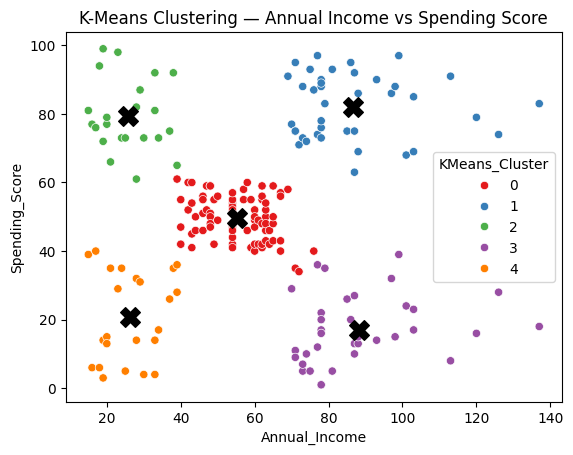

In [87]:
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='KMeans_Cluster', data=df, palette='Set1')
plt.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s=200)
plt.title('K-Means Clustering — Annual Income vs Spending Score')
plt.savefig('figure/kmeans.png',dpi=300)
plt.show()

#### Cluster profile table

In [90]:
cluster_names = [
    "The Middle Ground (Average Income, Moderate Spenders)",
    "VIPs / Premium Targets (High Income, High Spenders)",
    "Impulsive / Trendy Shoppers (Low Income, High Spenders)",
    "Untapped Potential (High Income, Low Spenders)",
    "Frugal Shoppers (Low Income, Low Spenders)"
]

In [98]:
pd.concat((pd.DataFrame(cluster_names,columns=['Cluster_Name']),df.groupby('KMeans_Cluster')[['Age','Annual_Income','Spending_Score']].mean()),axis=1)

,Cluster_Name,Age,Annual_Income,Spending_Score
0,"The Middle Ground (Average Income, Moderate Sp...",42.716049,55.296296,49.518519
1,"VIPs / Premium Targets (High Income, High Spen...",32.692308,86.538462,82.128205
2,"Impulsive / Trendy Shoppers (Low Income, High ...",25.272727,25.727273,79.363636
3,"Untapped Potential (High Income, Low Spenders)",41.114286,88.200000,17.114286
4,"Frugal Shoppers (Low Income, Low Spenders)",45.217391,26.304348,20.913043


## Task 4: Agglomerative Hierarchical Clustering 

#### Dendrogram

In [99]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [106]:
import numpy as np

In [102]:
linked = linkage(df_2f, method='ward')

In [125]:
# adding additional variable for cut line.

distances = linked[:, 2]

gaps = np.diff(distances)
largest_gap_idx = np.argmax(gaps)

cut_height = (distances[largest_gap_idx] + distances[largest_gap_idx + 1]) / 2

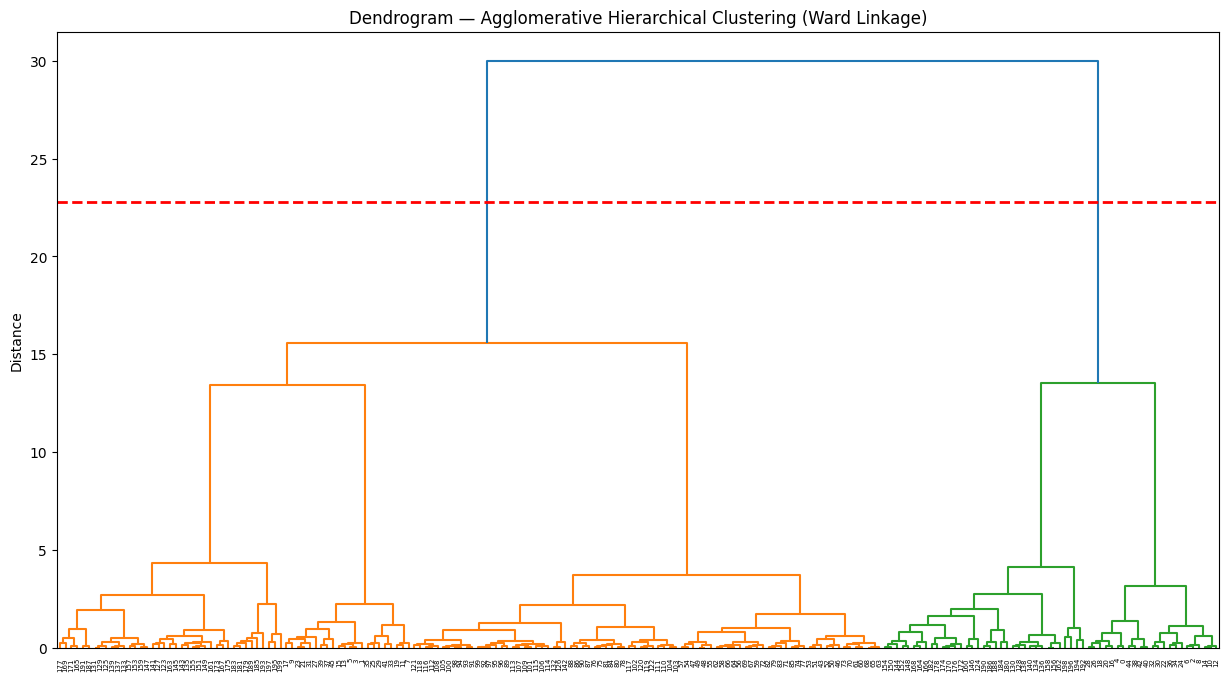

In [126]:
# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)')
plt.ylabel('Distance')
plt.axhline(y=cut_height, color="r", linestyle="--", linewidth=2, label=f"Optimal Cut (Height: {cut_height:.2f})")
plt.show()

---

##### Summary: Ward Linkage & Dendrogram Interpretation

* **What Ward Linkage Minimizes:** Instead of measuring distances between individual points, Ward's method minimizes the **total within-cluster variance**. At each stage of hierarchical clustering, it merges the two clusters that result in the smallest possible increase in the combined Sum of Squared Errors (SSE).
* **How to Choose the Number of Clusters:** Look for the **longest vertical lines** in the dendrogram that are not intersected by any horizontal merge steps. Drawing a horizontal threshold line through this maximum vertical gap creates an optimal cut; the number of vertical lines intersected by this threshold dictates your optimal number of clusters.

---

#### Fit Agglomerative model 

In [112]:
from sklearn.cluster import AgglomerativeClustering

In [127]:
agg_cluster = AgglomerativeClustering(n_clusters=5)

In [128]:
df['Hier_Cluster']=agg_cluster.fit_predict(df_2f)

#### Visualise Hierarchical clusters 

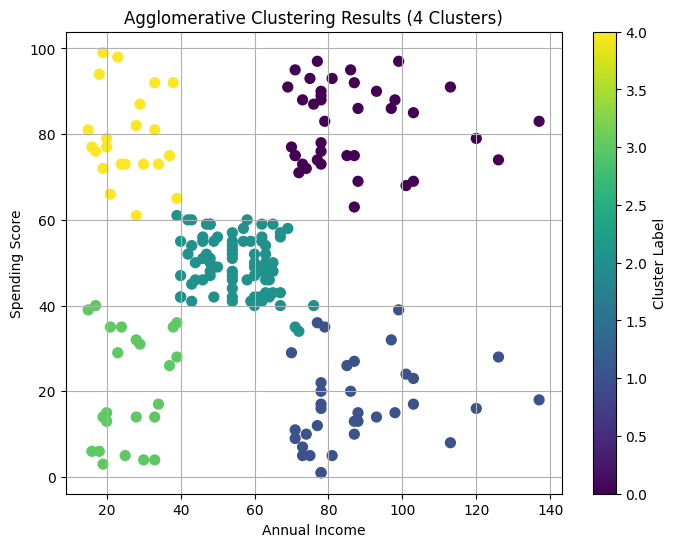

In [135]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Hier_Cluster'], s=50, cmap='viridis')
plt.title('Agglomerative Clustering Results (4 Clusters)')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.grid(True)
plt.colorbar(label='Cluster Label')
plt.savefig('figure/hier.png',dpi=300)
plt.show()